# Delhi NCR Air Quality Index — Exploratory Data Analysis
### A beginner-friendly, step-by-step guide

**What is EDA?**
Before building any machine learning model, we first need to *understand* our data.
EDA (Exploratory Data Analysis) is the process of:
- Looking at what the data contains
- Finding patterns and trends
- Spotting problems (missing values, outliers, weird distributions)
- Getting ideas for which features might be useful for prediction

Think of it like getting to know a new city before giving someone directions — you explore first, then navigate.

---


## Step 1 — Import libraries

Every Python ML project starts with importing libraries. Think of libraries as toolboxes — each one has tools for a specific job.


In [2]:
# pandas  → handles tabular data (like Excel, but in Python)
# numpy   → fast math operations on numbers
# matplotlib → base plotting library
# seaborn    → prettier statistical plots built on top of matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This line makes plots appear inside the notebook (not in a separate window)
%matplotlib inline

# Makes all plots look cleaner
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## Step 2 — Load the dataset

We use `pd.read_csv()` to load our CSV file into a **DataFrame**.
A DataFrame is like a table — rows are observations, columns are variables.


In [3]:
# Load the dataset
df = pd.read_csv('../data/delhi_ncr_aqi_dataset.csv')

# .shape tells us (number of rows, number of columns)
print(f"Dataset shape: {df.shape}")
print(f"→ {df.shape[0]:,} rows (hourly readings)")
print(f"→ {df.shape[1]} columns (features)")


Dataset shape: (201664, 25)
→ 201,664 rows (hourly readings)
→ 25 columns (features)


In [4]:
# .head() shows the first 5 rows — your first look at the data
df.head()


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [5]:
# .columns lists all column names
print("Columns in our dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")


Columns in our dataset:
   1. datetime
   2. date
   3. year
   4. month
   5. day
   6. hour
   7. day_of_week
   8. is_weekend
   9. season
  10. city
  11. station
  12. latitude
  13. longitude
  14. pm25
  15. pm10
  16. no2
  17. so2
  18. co
  19. o3
  20. temperature
  21. humidity
  22. wind_speed
  23. visibility
  24. aqi
  25. aqi_category


---
## Step 3 — Understand data types and structure

Each column has a **data type** (dtype):
- `int64` → whole numbers (e.g., year, month)
- `float64` → decimal numbers (e.g., pm25, temperature)
- `object` → text/string (e.g., city, season)

This matters because ML models only understand numbers — text columns need special treatment later.


In [6]:
# .info() gives a quick summary: column names, non-null counts, dtypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

In [7]:
# Count how many columns are numeric vs text
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
text_cols    = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print()
print(f"Text columns ({len(text_cols)}): {text_cols}")


Numeric columns (18): ['year', 'month', 'day', 'hour', 'is_weekend', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']

Text columns (7): ['datetime', 'date', 'day_of_week', 'season', 'city', 'station', 'aqi_category']


---
## Step 4 — Check for missing values

Missing values are one of the most common problems in real datasets.
If we don't handle them, our ML model will crash or give wrong results.

Luckily, our dataset has **zero missing values** — but it's always good practice to check!


🎉 Great news! No missing values found in any column.


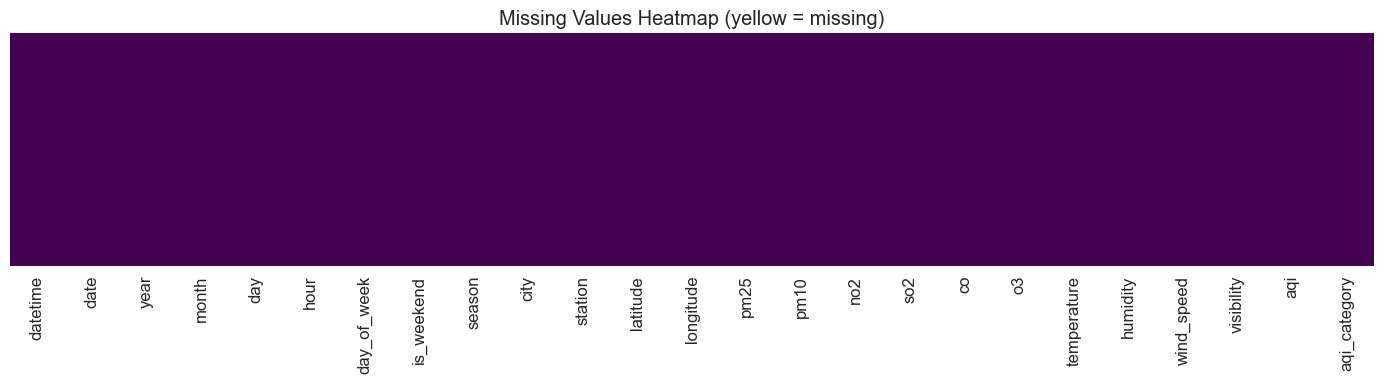

In [8]:
# .isnull().sum() counts missing values per column
missing = df.isnull().sum()

if missing.sum() == 0:
    print("🎉 Great news! No missing values found in any column.")
else:
    print("⚠️ Missing values found:")
    print(missing[missing > 0])

# Visualize missing values as a heatmap (will be empty for our dataset)
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap (yellow = missing)")
plt.tight_layout()
plt.show()


---
## Step 5 — Basic statistics

`.describe()` is one of the most useful functions in pandas.
It shows count, mean, standard deviation, min, max, and percentiles for every numeric column.

**Key terms:**
- **mean** → average value
- **std** → standard deviation (how spread out the values are)
- **25% / 50% / 75%** → quartiles (25% of data is below the 25% value, etc.)


In [9]:
# Descriptive statistics for all numeric columns
# .T transposes the table (rows become columns) so it's easier to read
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
year,201664.0,2022.50,1.71,2020.00,2021.00,2022.50,2024.00,2025.00
month,201664.0,6.52,3.45,1.00,4.00,7.00,10.00,12.00
day,201664.0,15.73,8.80,1.00,8.00,16.00,23.00,31.00
hour,201664.0,14.75,6.38,6.00,10.50,15.00,19.25,23.00
is_weekend,201664.0,0.29,0.45,0.00,0.00,0.00,1.00,1.00
latitude,201664.0,28.60,0.11,28.37,28.53,28.62,28.67,28.78
longitude,201664.0,77.21,0.13,77.03,77.07,77.20,77.32,77.50
pm25,201664.0,183.42,193.14,15.00,55.30,99.50,254.70,900.00
pm10,201664.0,348.57,370.02,24.00,104.10,189.80,481.20,1979.70
no2,201664.0,69.76,75.97,8.00,19.90,38.30,94.00,593.50


In [10]:
# Let's focus on the pollutant columns specifically
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
print("=== Pollutant Statistics ===")
df[pollutants].describe().T.round(2)


=== Pollutant Statistics ===


,count,mean,std,min,25%,50%,75%,max
pm25,201664.0,183.42,193.14,15.0,55.30,99.50,254.70,900.00
pm10,201664.0,348.57,370.02,24.0,104.10,189.80,481.20,1979.70
no2,201664.0,69.76,75.97,8.0,19.90,38.30,94.00,593.50
so2,201664.0,16.03,17.20,4.0,4.50,8.70,20.90,121.60
co,201664.0,3.03,3.28,0.3,0.87,1.69,4.12,22.67
o3,201664.0,27.19,13.57,12.0,18.00,23.30,31.80,84.00


---
## Step 6 — Understand the target variable (AQI)

Our **target variable** is what we want to predict — in this case, `aqi`.
Understanding its distribution is crucial before building any model.

**AQI Scale (India):**
| AQI Range | Category |
|-----------|----------|
| 0–50      | Good |
| 51–100    | Satisfactory |
| 101–200   | Moderate |
| 201–300   | Poor |
| 301–400   | Very Poor |
| 401–500   | Severe |


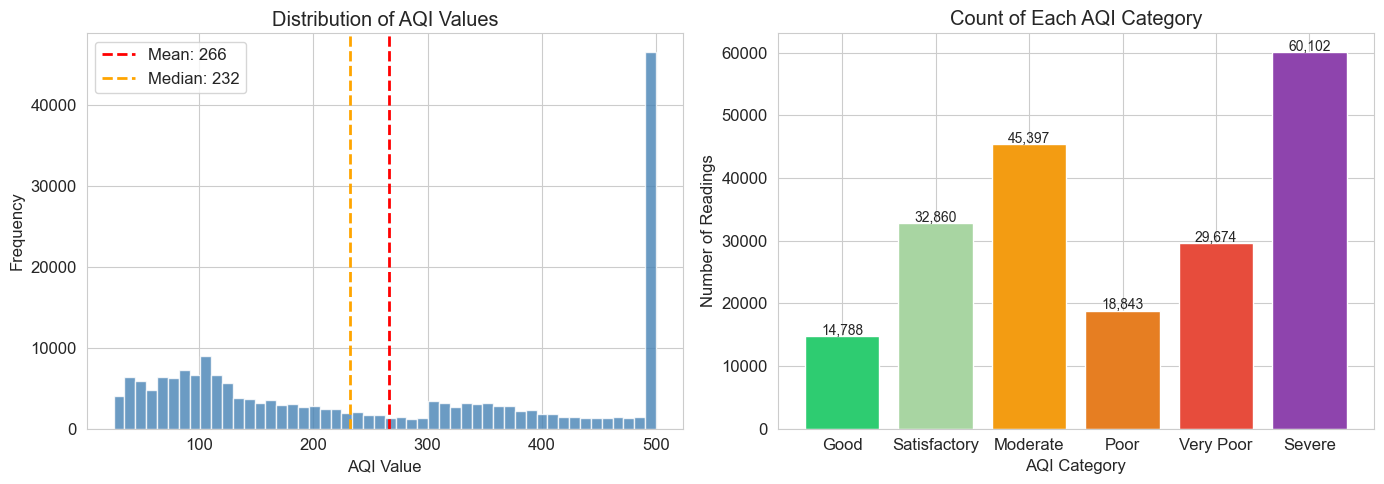


AQI Summary:
  Min:    25
  Max:    500
  Mean:   265.8
  Median: 232.0

AQI is right-skewed — most readings cluster in the Moderate-Severe range.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AQI distribution histogram
axes[0].hist(df['aqi'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['aqi'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['aqi'].mean():.0f}")
axes[0].axvline(df['aqi'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['aqi'].median():.0f}")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of AQI Values")
axes[0].legend()

# Right: AQI category counts
cat_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_colors = ['#2ecc71', '#a8d5a2', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
cat_counts = df['aqi_category'].value_counts().reindex(cat_order)

axes[1].bar(cat_counts.index, cat_counts.values, color=cat_colors, edgecolor='white')
axes[1].set_xlabel("AQI Category")
axes[1].set_ylabel("Number of Readings")
axes[1].set_title("Count of Each AQI Category")
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nAQI Summary:")
print(f"  Min:    {df['aqi'].min()}")
print(f"  Max:    {df['aqi'].max()}")
print(f"  Mean:   {df['aqi'].mean():.1f}")
print(f"  Median: {df['aqi'].median():.1f}")
print(f"\nAQI is right-skewed — most readings cluster in the Moderate-Severe range.")


---
## Step 7 — Temporal patterns (How AQI changes over time)

Time-based patterns are very important for this dataset.
Delhi's air quality is strongly seasonal — winters are terrible, monsoons are better.


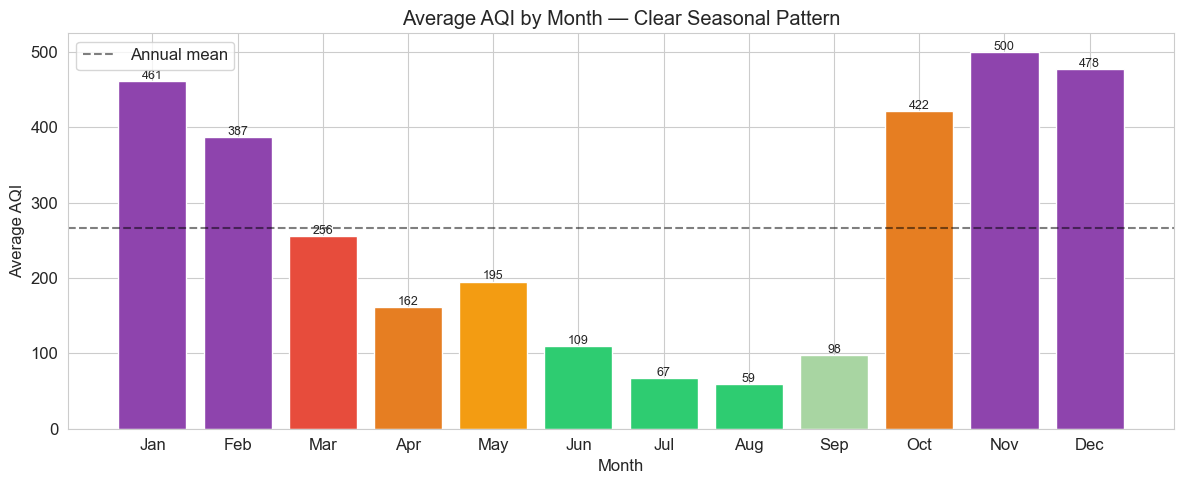

Key insight: AQI is highest in winter (Oct–Jan) due to crop burning + cold air trapping pollutants.
AQI is lowest in monsoon (Jul–Sep) because rain washes pollutants away.


In [12]:
# Average AQI by Month
monthly_aqi = df.groupby('month')['aqi'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
bars = plt.bar(month_names, monthly_aqi.values, 
               color=['#8e44ad','#8e44ad','#e74c3c','#e67e22','#f39c12',
                      '#2ecc71','#2ecc71','#2ecc71','#a8d5a2','#e67e22','#8e44ad','#8e44ad'],
               edgecolor='white')
plt.axhline(monthly_aqi.mean(), color='black', linestyle='--', alpha=0.5, label='Annual mean')
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Average AQI by Month — Clear Seasonal Pattern")
plt.legend()
for bar, val in zip(bars, monthly_aqi.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
             f'{val:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Key insight: AQI is highest in winter (Oct–Jan) due to crop burning + cold air trapping pollutants.")
print("AQI is lowest in monsoon (Jul–Sep) because rain washes pollutants away.")


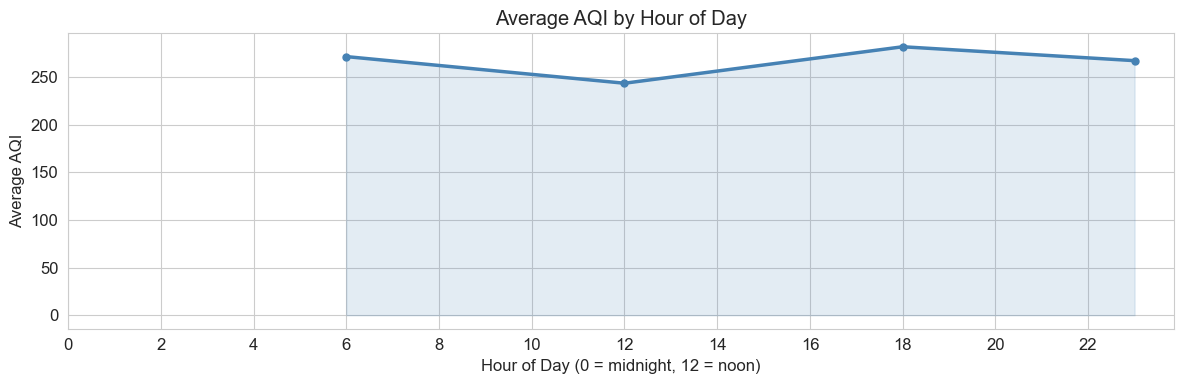

Insight: AQI is higher in early morning (traffic + cold air) and lower in afternoon (sunlight + air movement).


In [13]:
# Average AQI by Hour of Day
hourly_aqi = df.groupby('hour')['aqi'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly_aqi.index, hourly_aqi.values, color='steelblue', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(hourly_aqi.index, hourly_aqi.values, alpha=0.15, color='steelblue')
plt.xlabel("Hour of Day (0 = midnight, 12 = noon)")
plt.ylabel("Average AQI")
plt.title("Average AQI by Hour of Day")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print("Insight: AQI is higher in early morning (traffic + cold air) and lower in afternoon (sunlight + air movement).")


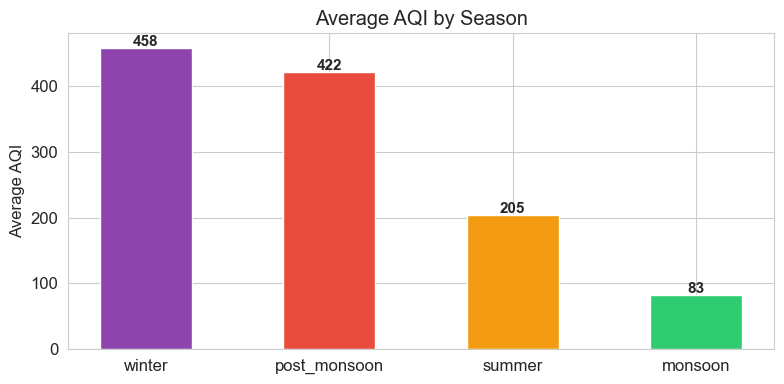

In [14]:
# Average AQI by Season
season_aqi = df.groupby('season')['aqi'].mean().sort_values(ascending=False)

colors = {'winter': '#8e44ad', 'post_monsoon': '#e74c3c', 'summer': '#f39c12', 'monsoon': '#2ecc71'}

plt.figure(figsize=(8, 4))
bars = plt.bar(season_aqi.index, season_aqi.values,
               color=[colors[s] for s in season_aqi.index],
               edgecolor='white', width=0.5)
plt.ylabel("Average AQI")
plt.title("Average AQI by Season")
for bar, val in zip(bars, season_aqi.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 8 — Compare cities

Our dataset has 5 cities in the Delhi NCR region.
Are some cities more polluted than others? Let's find out.


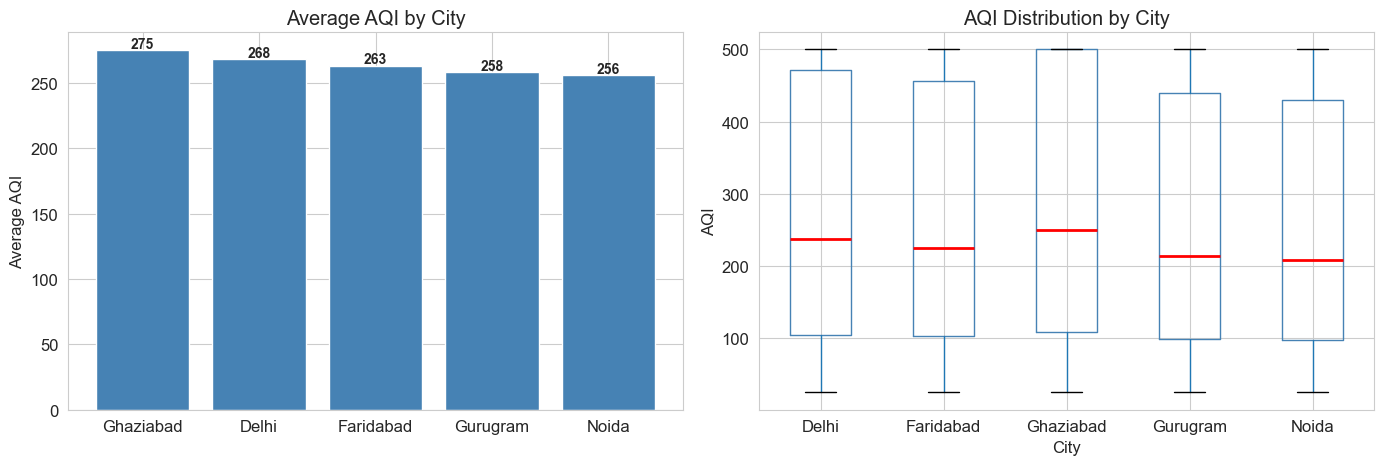

Box plot explained:
  - The box = middle 50% of data (25th to 75th percentile)
  - Red line = median (middle value)
  - Whiskers = range of most data
  - Dots above = outliers (unusually high AQI readings)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average AQI by city
city_aqi = df.groupby('city')['aqi'].mean().sort_values(ascending=False)
axes[0].bar(city_aqi.index, city_aqi.values, color='steelblue', edgecolor='white')
axes[0].set_ylabel("Average AQI")
axes[0].set_title("Average AQI by City")
for i, (city, val) in enumerate(city_aqi.items()):
    axes[0].text(i, val + 2, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

# Right: Box plot — shows distribution, not just average
df.boxplot(column='aqi', by='city', ax=axes[1], 
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title("AQI Distribution by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("AQI")
plt.suptitle("")  # removes default "Boxplot grouped by city" title

plt.tight_layout()
plt.show()

print("Box plot explained:")
print("  - The box = middle 50% of data (25th to 75th percentile)")
print("  - Red line = median (middle value)")
print("  - Whiskers = range of most data")
print("  - Dots above = outliers (unusually high AQI readings)")


---
## Step 9 — Pollutant distributions

Let's look at how each pollutant is distributed.
This helps us understand which pollutants are most common and extreme.


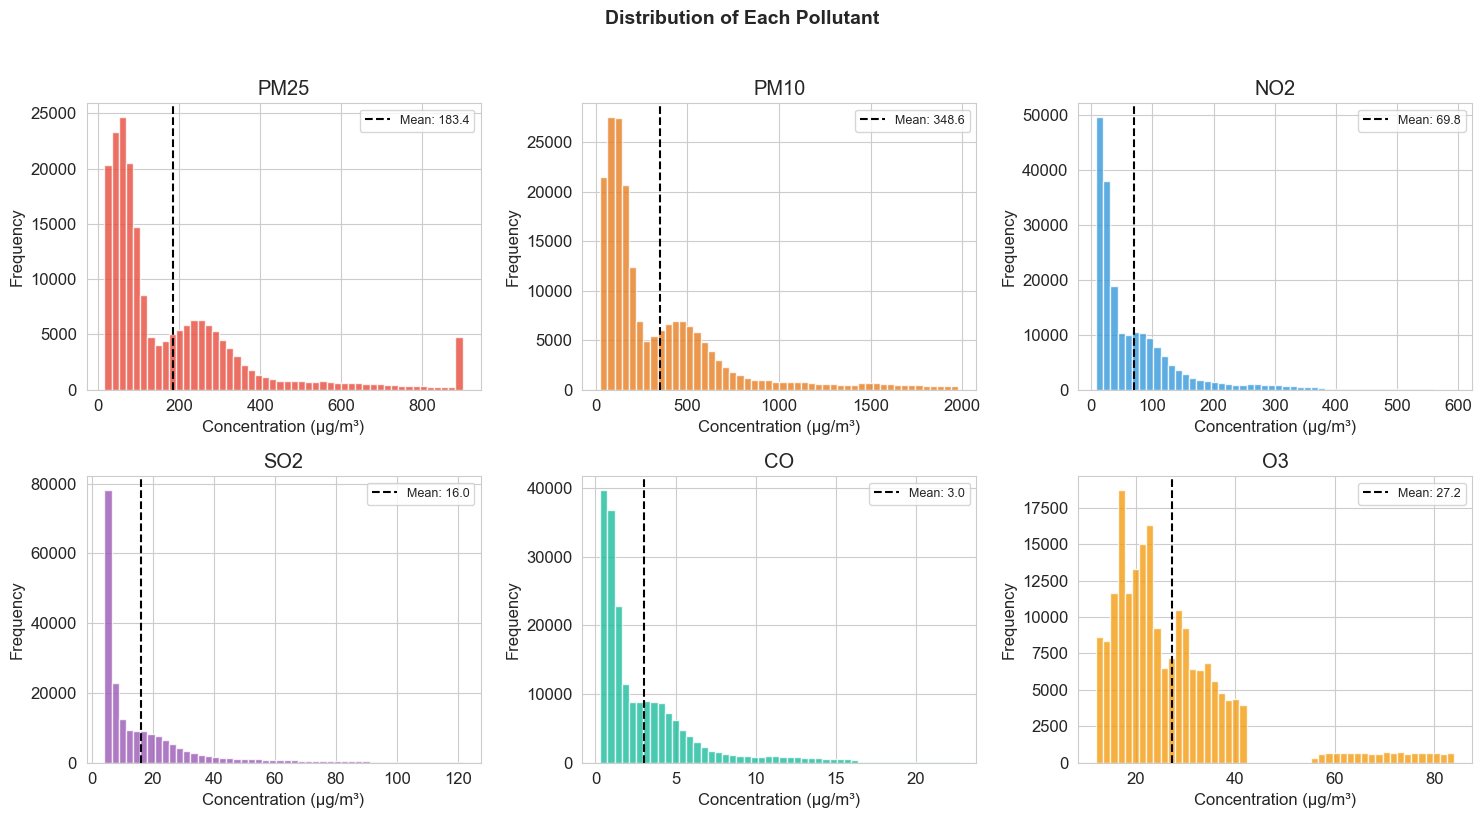

Notice: PM2.5 and PM10 have long right tails — most days are moderate
but some days have extremely high pollution (spikes from crop burning, festivals).


In [16]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#1abc9c', '#f39c12']

for i, (col, color) in enumerate(zip(pollutants, colors)):
    axes[i].hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, 
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col.upper())
    axes[i].set_xlabel("Concentration (μg/m³)")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)

plt.suptitle("Distribution of Each Pollutant", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Notice: PM2.5 and PM10 have long right tails — most days are moderate")
print("but some days have extremely high pollution (spikes from crop burning, festivals).")


---
## Step 10 — Correlation analysis

**Correlation** measures how strongly two variables move together:
- `+1.0` → perfect positive correlation (both go up together)
- `-1.0` → perfect negative correlation (one goes up, other goes down)
- `0` → no relationship

This is one of the most important steps — it tells us **which features will be useful** for predicting AQI.


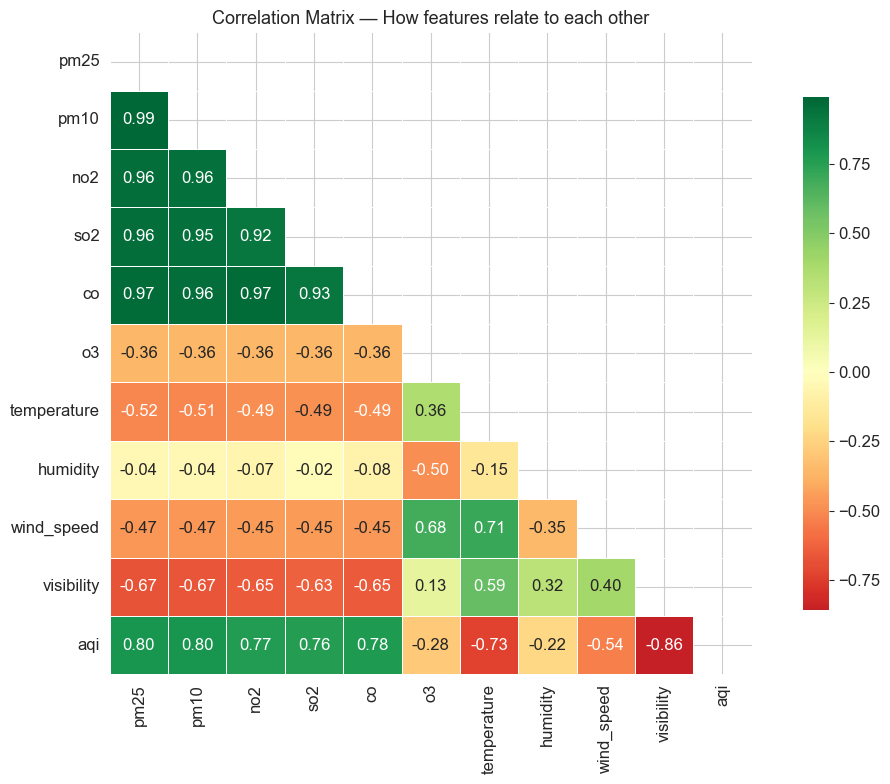

In [17]:
# Select only numeric columns relevant for ML
numeric_df = df[['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 
                  'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle

sns.heatmap(corr_matrix, 
            annot=True,       # Show numbers inside cells
            fmt=".2f",        # 2 decimal places
            cmap="RdYlGn",    # Red=negative, Green=positive
            center=0,
            mask=mask,
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix — How features relate to each other", fontsize=13)
plt.tight_layout()
plt.show()


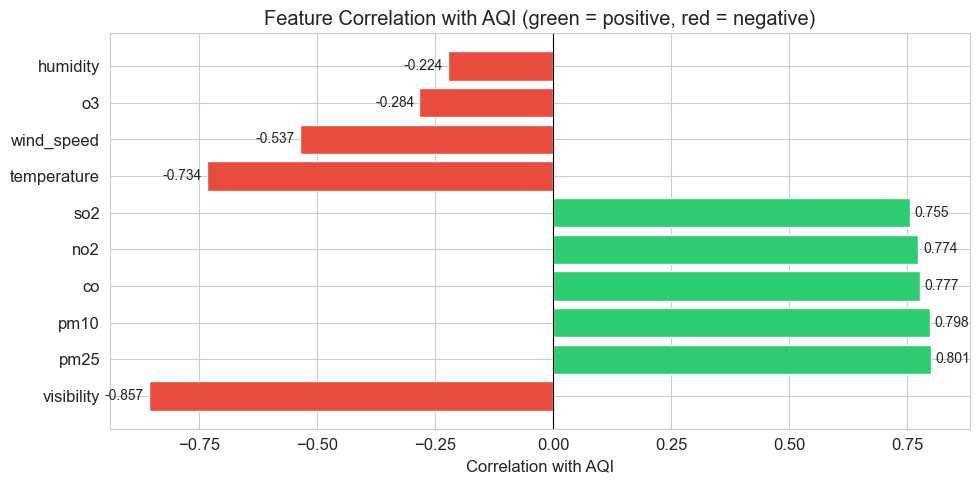

Key findings:
  Strongest POSITIVE correlation with AQI: pm25 (0.801)
  Strongest NEGATIVE correlation with AQI: humidity (-0.224)

Negative correlations make intuitive sense:
  - visibility ↑  →  AQI ↓  (clear sky = clean air)
  - wind_speed ↑  →  AQI ↓  (wind disperses pollutants)
  - temperature ↑ →  AQI ↓  (warm air rises, carrying pollutants up)


In [18]:
# The most important question: which features correlate MOST with AQI?
aqi_corr = corr_matrix['aqi'].drop('aqi').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in aqi_corr.values]
bars = plt.barh(aqi_corr.index, aqi_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlation with AQI")
plt.title("Feature Correlation with AQI (green = positive, red = negative)")
for bar, val in zip(bars, aqi_corr.values):
    plt.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()

print("Key findings:")
print(f"  Strongest POSITIVE correlation with AQI: {aqi_corr[aqi_corr > 0].index[0]} ({aqi_corr[aqi_corr > 0].values[0]:.3f})")
print(f"  Strongest NEGATIVE correlation with AQI: {aqi_corr[aqi_corr < 0].index[-1]} ({aqi_corr[aqi_corr < 0].values[-1]:.3f})")
print()
print("Negative correlations make intuitive sense:")
print("  - visibility ↑  →  AQI ↓  (clear sky = clean air)")
print("  - wind_speed ↑  →  AQI ↓  (wind disperses pollutants)")
print("  - temperature ↑ →  AQI ↓  (warm air rises, carrying pollutants up)")


---
## Step 11 — Scatter plots (Visual relationships)

Scatter plots let us *see* the relationship between two variables.
This is more informative than just a correlation number.


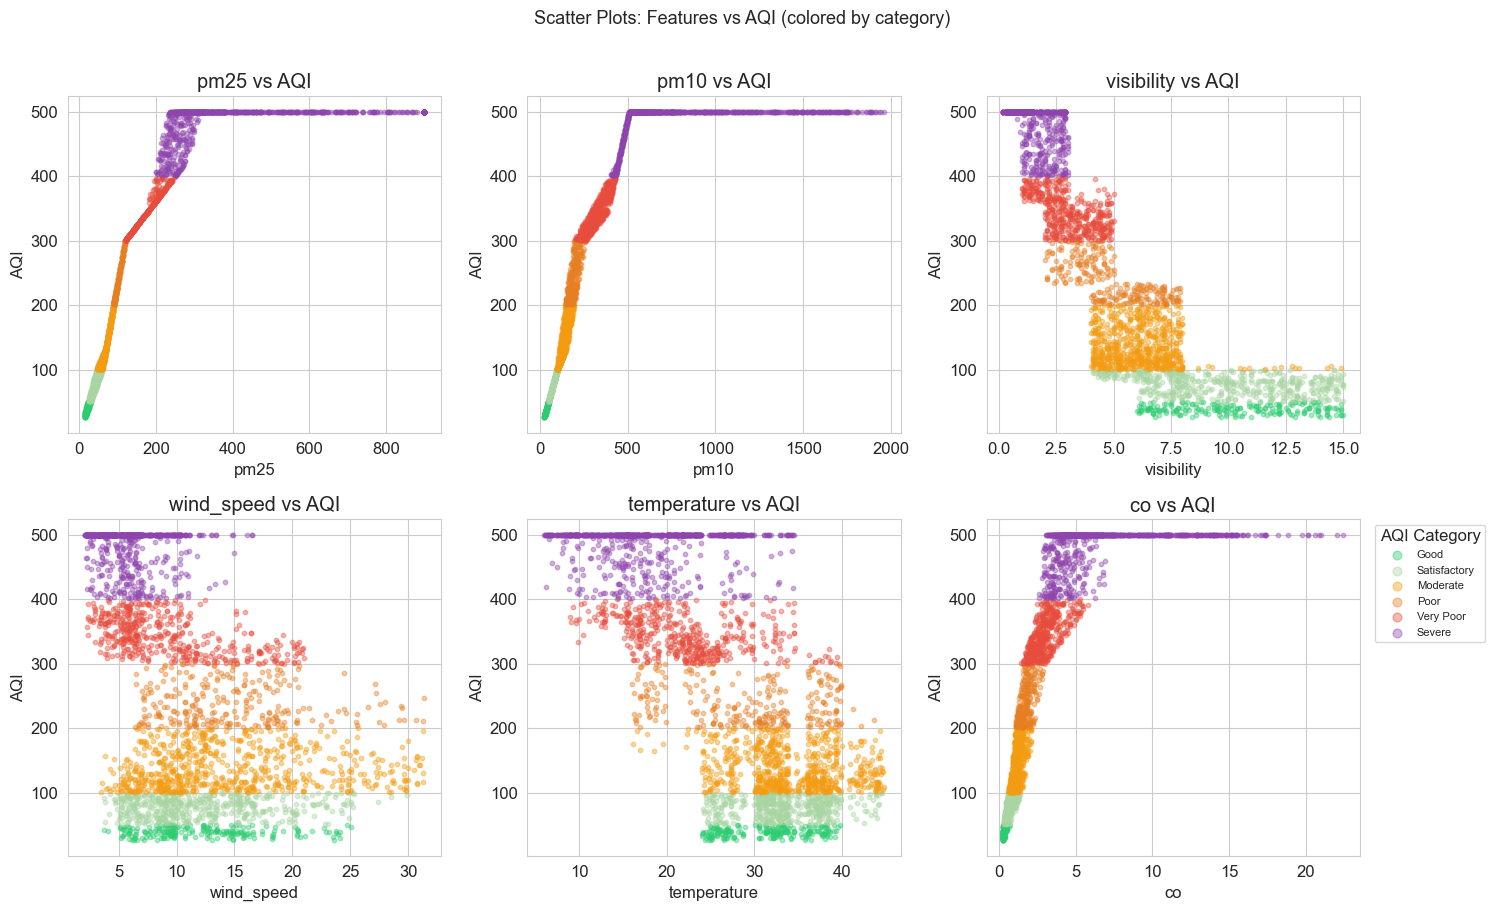

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

features = ['pm25', 'pm10', 'visibility', 'wind_speed', 'temperature', 'co']
colors_map = {'Good': '#2ecc71', 'Satisfactory': '#a8d5a2', 'Moderate': '#f39c12',
              'Poor': '#e67e22', 'Very Poor': '#e74c3c', 'Severe': '#8e44ad'}

# Sample 3000 points so the plot isn't overcrowded
sample = df.sample(3000, random_state=42)

for i, feat in enumerate(features):
    for cat, color in colors_map.items():
        mask = sample['aqi_category'] == cat
        axes[i].scatter(sample[mask][feat], sample[mask]['aqi'],
                        c=color, alpha=0.4, s=10, label=cat)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("AQI")
    axes[i].set_title(f"{feat} vs AQI")

# Add legend to the last plot
axes[-1].legend(title="AQI Category", fontsize=8, markerscale=2,
                loc='upper right', bbox_to_anchor=(1.35, 1))

plt.suptitle("Scatter Plots: Features vs AQI (colored by category)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## Step 12 — Weekend vs weekday patterns

Does AQI differ between weekdays and weekends? Less traffic on weekends might mean cleaner air.


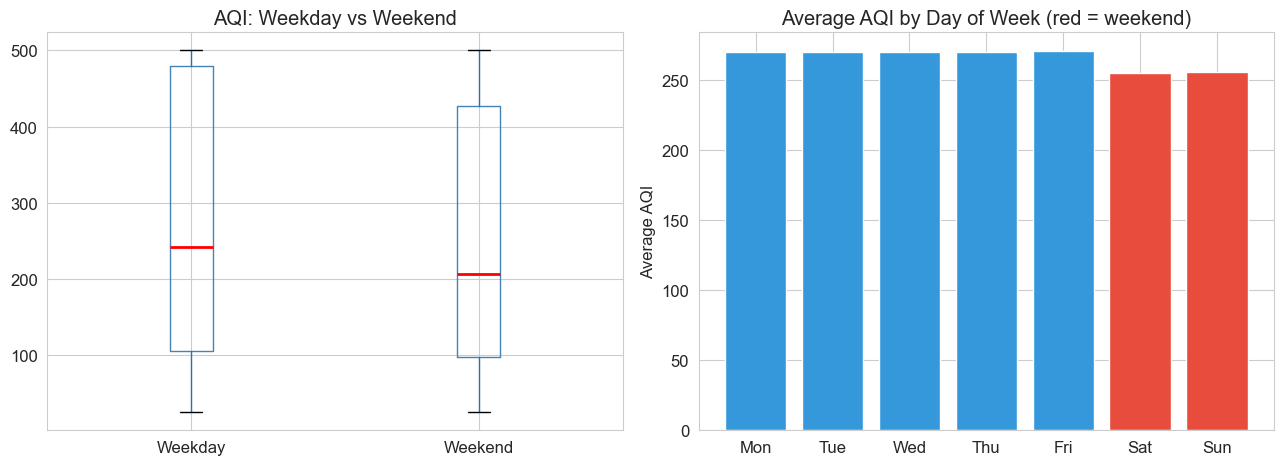

Weekday avg AQI: 270.0
Weekend avg AQI: 255.3
Difference: 14.7 AQI points (weekdays worse)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot: weekday vs weekend
df['day_type'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
df.boxplot(column='aqi', by='day_type', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title("AQI: Weekday vs Weekend")
axes[0].set_xlabel("")
plt.suptitle("")

# Average AQI by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_aqi = df.groupby('day_of_week')['aqi'].mean().reindex(day_order)
axes[1].bar(range(7), day_aqi.values,
            color=['#3498db']*5 + ['#e74c3c']*2, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_ylabel("Average AQI")
axes[1].set_title("Average AQI by Day of Week (red = weekend)")

plt.tight_layout()
plt.show()

wd = df[df['is_weekend']==0]['aqi'].mean()
we = df[df['is_weekend']==1]['aqi'].mean()
print(f"Weekday avg AQI: {wd:.1f}")
print(f"Weekend avg AQI: {we:.1f}")
print(f"Difference: {abs(wd-we):.1f} AQI points ({'weekdays worse' if wd > we else 'weekends worse'})")


---
## Step 13 — Year-over-year trend

Is Delhi's air quality getting better or worse over the years?


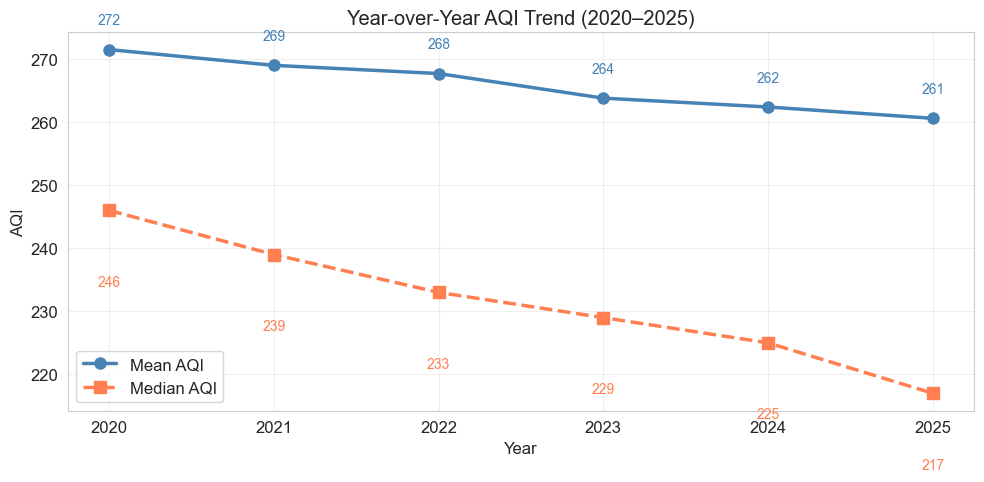

Yearly stats:
       mean  median
year               
2020  271.5   246.0
2021  269.0   239.0
2022  267.7   233.0
2023  263.8   229.0
2024  262.4   225.0
2025  260.6   217.0


In [21]:
yearly_aqi = df.groupby('year')['aqi'].agg(['mean', 'median']).round(1)

plt.figure(figsize=(10, 5))
plt.plot(yearly_aqi.index, yearly_aqi['mean'], marker='o', linewidth=2.5,
         color='steelblue', label='Mean AQI', markersize=8)
plt.plot(yearly_aqi.index, yearly_aqi['median'], marker='s', linewidth=2.5,
         color='coral', linestyle='--', label='Median AQI', markersize=8)

for yr, row in yearly_aqi.iterrows():
    plt.text(yr, row['mean'] + 4, f"{row['mean']:.0f}", ha='center', fontsize=10, color='steelblue')
    plt.text(yr, row['median'] - 12, f"{row['median']:.0f}", ha='center', fontsize=10, color='coral')

plt.xlabel("Year")
plt.ylabel("AQI")
plt.title("Year-over-Year AQI Trend (2020–2025)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Yearly stats:")
print(yearly_aqi)


---
## Step 14 — EDA Summary & Key Insights

Congratulations! You've completed a full exploratory data analysis. Here's what we learned:

### 🔍 Dataset overview
- **201,664 rows**, **25 columns**, **0 missing values** — very clean dataset
- Covers **5 cities** in Delhi NCR from **2020 to 2025**
- Contains both a regression target (`aqi`) and a classification target (`aqi_category`)

### 📊 Key patterns found
1. **Seasonal pattern**: Winter (Oct–Jan) has the worst AQI due to crop burning & cold air trapping pollutants. Monsoon (Jul–Sep) is best because rain cleans the air.
2. **Time of day**: Early morning is most polluted; afternoons are relatively cleaner.
3. **City differences**: Some NCR cities are consistently more polluted than others.
4. **Most important features for ML**:
   - **Positive**: PM2.5, PM10, CO, NO2, SO2 (more = worse air)
   - **Negative**: Visibility, Wind speed, Temperature (more = better air)

### 🚀 What's next?
In Phase 2 (Data Preprocessing), we will:
- Drop columns that aren't useful for ML (like datetime strings)
- Convert text columns into numbers (label encoding)
- Scale numeric features so they're all on the same range
- Split the data into training and test sets

---
*End of EDA Notebook*
